# 12_时间序列分析方法-Prophet

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今天，咱们分享的Prophet是非常好用且效果不错的一个模型，Prophet最初是由Facebook 开发，用来帮助预测数据的未来趋势。

简单来说，时间序列预测就是通过分析历史数据，猜测未来会发生什么。比如你有过去几年每天的销售额数据，想预测明年的销售额趋势，Prophet 就是用来做这个的工具。

咱们简单的来解释一下Prophet\~

1. **理解历史数据的趋势**：假设你想知道接下来几个月的销售额会怎么样，Prophet 首先会分析过去的数据，看有没有什么长期趋势，比如你的销售额是不是一年比一年增加，或者有时是减少的。
2. **找出季节性变化**：Prophet 还会查看有没有周期性的规律，比如每年夏天销售额会高一点，或者每周的周末销售比平时好。这样，它能识别出这些周期性的波动。
3. **添加假期影响**：如果你的数据里有节假日，Prophet 也能考虑进去，比如圣诞节期间销售额通常会暴涨，工具会识别出这种假期效应，做出更精准的预测。
4. **预测未来趋势**：综合这些信息后，Prophet 会根据已经找到的模式，推测未来会是什么样的趋势，比如未来几个月的销售额大概会怎么变化。

### Prophet 的优点

- **简单好用**：即使你不是数据科学专家，Prophet 也比较容易上手。你只需要提供历史数据，它就能自动做出预测。
- **灵活性强**：它能处理各种类型的时间序列数据，不管是每天、每小时甚至每分钟的数据。
- **可解释性好**：Prophet 生成的模型容易理解，你可以清楚地看到它是怎么分析数据的，以及哪些因素影响了预测。

Prophet 就是个帮你根据过去的数据信息，自动预测未来变化趋势的小工具，操作起来不复杂，非常适合初学者用来做时间序列预测的入门工具。

## 理论基础

Prophet 是一种基于**加性模型**，能够分解时间序列为多个不同的部分：**趋势（Trend）**、**季节性（Seasonality）和假期效应（Holidays effects）**。

在详细讲解 Prophet 的数学原理之前，咱们需要理解它的基本结构\~

Prophet 模型公式可以表示为：


$$
y(t) = g(t) + s(t) + h(t) + \epsilon_t
$$


其中：

- $y(t)$是时间 $t$时刻的观测值（即实际的时间序列数据）。
- $g(t)$是时间 $t$时刻的**趋势**函数，描述数据的长期趋势。
- $s(t)$是时间 $t$时刻的**季节性**函数，捕捉周期性的波动。
- $h(t)$是时间 $t$时刻的**假期效应**，用于建模特殊事件或假期对数据的影响。
- $\epsilon_t$是噪声项或误差项，通常假设其服从正态分布。

接下来，咱们详细介绍 Prophet 各个部分的数学原理。

### 1. 趋势（Trend）模型：$g(t)$

Prophet 提供了两种趋势模型：**线性趋势**和**logistic（逻辑）增长趋势**。

#### 线性趋势

线性趋势用于建模随时间呈现线性变化的情况。它的数学公式为：


$$
g(t) = (k + \delta(t)) t + (m + \gamma(t))
$$


其中：

- $k$是线性增长速率。
- $\delta(t)$是变化点（change points）在特定时间点发生速率变化的调整项。
- $m$是截距（y 轴上的初始值）。
- $\gamma(t)$是截距变化的调整项。

Prophet 会在历史数据中自动识别变化点，即趋势突然发生变化的时间点。在这些变化点，模型中的斜率 $k$会进行调整，以适应新的增长趋势。

#### Logistic 增长趋势

Logistic 增长趋势用于建模增长有上限的情况（如市场饱和）。logistic 增长趋势的公式为：


$$
g(t) = \frac{C}{1 + \exp(-k(t - m))}
$$


其中：

- $C$是增长的上限（即饱和值）。
- $k$是增长速率。
- $m$是曲线的中心点，即曲线增长最快时的时间点。

Logistic 模型特别适合那些增长一开始很快，但最终趋向于稳定或饱和的数据场景，比如市场中的产品销售，随着时间推移，增长会逐渐减慢。

### 2. 季节性（Seasonality）模型：$s(t)$

季节性函数 $s(t)$负责捕捉周期性波动，比如销售额的周末效应或每年的季节性波动。Prophet 使用傅里叶级数来近似表达季节性变化：


$$
s(t) = \sum_{n=1}^{N} \left( a_n \cos \left( \frac{2 \pi n t}{P} \right) + b_n \sin \left( \frac{2 \pi n t}{P} \right) \right)
$$


其中：

- $P$是季节性的周期长度（例如一年为 365.25 天，或者一周为 7 天）。
- $a_n$和 $b_n$是傅里叶系数，反映了每个正弦波分量的权重。
- $N$是傅里叶级数的阶数，决定了模型的复杂度。较大的 $N$可以捕捉更复杂的周期模式。

傅里叶级数的优势在于可以有效表达任何周期性波动，不管波动是简单的正弦曲线还是更复杂的周期性变化。

### 3. 假期效应（Holiday Effects）：$h(t)$

假期效应 $h(t)$模型用来处理特定日期或时间段对时间序列的短期影响。它使用一个指示函数来表示某些假期或特殊事件：


$$
h(t) = \sum_{i=1}^{L} \left( \alpha_i \mathbf{1}(t \in \mathcal{H}_i) \right)
$$


其中：

- $\mathcal{H}_i$表示第 $i$个假期的时间段。
- $\mathbf{1}(t \in \mathcal{H}_i)$是一个指示函数，当 $t$在假期 $\mathcal{H}_i$期间时，取值为 1，否则为 0。
- $\alpha_i$表示假期对数据的影响程度。

Prophet 不仅可以处理假期当天的影响，还可以处理假期前后的效应（如假期前的购物高峰和假期后的疲软期）。用户可以手动指定假期和相关日期，模型会根据数据自适应地学习这些效应的强度。

### 4. 误差项（Residual/Error）：$\epsilon_t$

$\epsilon_t$是误差项，表示模型和实际数据之间的差异。通常假设误差服从正态分布，即 $\epsilon_t \sim \mathcal{N}(0, \sigma^2)$，其中 $\sigma$是标准差。

Prophet 在拟合模型时，使用最大似然估计（Maximum Likelihood Estimation，MLE）方法来找到最优参数，最小化模型的误差。

### 5. 模型拟合与优化

Prophet 的核心目标是通过对趋势、季节性和假期效应的加性分解来拟合时间序列数据。为了优化模型，Prophet 使用了斯坦（Stan）库，斯坦是一个用于贝叶斯推理的概率编程语言。具体来说，Prophet 使用了广义的极大似然估计（Generalized Maximum Likelihood Estimation）和马尔科夫链蒙特卡洛（MCMC）方法来估计模型参数。

Prophet 首先将所有的趋势、季节性和假期效应参数转化为一个优化问题，接着通过斯坦模型优化这些参数。拟合过程中，它会根据历史数据自适应地选择变化点和季节性周期，尽可能准确地捕捉数据中的变化模式。

### 6. 预测过程

拟合好模型之后，Prophet 用这个模型来进行未来的预测。预测的步骤是：

1. 对未来的时间点使用拟合好的 $g(t)$（趋势），估计它的趋势值。
2. 使用 $s(t)$来计算未来时间点的季节性波动。
3. 如果未来时间点有假期效应，则考虑 $h(t)$的影响。
4. 最终的预测值为这几个部分的加总，即 $y(t) = g(t) + s(t) + h(t)$，再加上噪声 $\epsilon_t$。

### 总结 Prophet 算法流程

1. **输入数据**：输入一段时间序列数据 $y(t)$以及对应的时间戳 $t$。
2. **趋势建模**：

   - 如果是线性趋势，则通过拟合 $g(t) = kt + m$的形式来拟合数据。
   - 如果是 Logistic 增长趋势，则通过拟合 $g(t) = \frac{C}{1 + \exp(-k(t - m))}$来模拟饱和增长。
3. **季节性建模**：使用傅里叶级数建模 $s(t)$，并找到周期性波动模式。
4. **假期建模**：根据提供的假期列表，调整模型，加入假期效应 $h(t)$。
5. **误差处理**：拟合过程中考虑误差项 $\epsilon_t$，通常假设为正态分布。
6. **参数优化**：使用斯坦模型来优化参数，最小化误差。
7. **预测未来**：基于拟合的趋势、季节性和假期效应，预测未来的时间序列值。

Prophet 通过这种加性分解方法，可以非常灵活地处理各种复杂的时间序列数据。

## 一个完整案例

下面给大家展示使用 Prophet 进行时间序列预测，结合实际数据进行数据分析\~

当一家零售公司，希望预测未来一年的销售额趋势，并且想要考虑季节性、假期效应以及趋势变化点等因素。

咱们将使用 Prophet 来预测和分析销售额数据。

#### Step 1: 数据准备

咱们将从一个包含历史销售额数据的数据集中开始。

该数据集包含以下列：

- 日期（`date`）：销售日期
- 销售额（`sales`）：该日期的实际销售额
- 假期信息（可选）：特殊日期，如圣诞节、黑色星期五等

在这个例子中，咱们假设已经有了这类数据并将其导入 Python 环境。

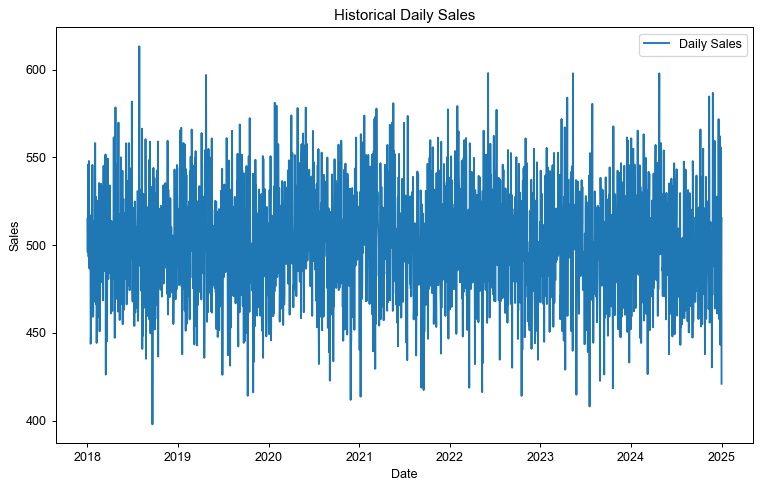

In [2]:
import pandas as pd
import numpy as np
from prophet import Prophet
import matplotlib.pyplot as plt

# 创建示例销售数据集，假设是从2018年到2023年的每日销售额
date_range = pd.date_range(start='2018-01-01', end='2024-12-31')
np.random.seed(42)
sales = 500 + 5 * np.sin(2 * np.pi * date_range.dayofyear / 365.25) + np.random.normal(0, 30, len(date_range))

# 创建一个 DataFrame 存储数据
data = pd.DataFrame({
    'date': date_range,
    'sales': sales
})

# 将列名转换为 Prophet 要求的 'ds' 和 'y'
data.rename(columns={'date': 'ds', 'sales': 'y'}, inplace=True)

# 可视化数据
plt.figure(figsize=(10, 6))
plt.plot(data['ds'], data['y'], label='Daily Sales')
plt.title('Historical Daily Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

在这一步中，咱们生成了一个销售额随时间变化的图表，显示了每天的销售趋势。

![原文参考图，当前结果见代码输出](attachments/img_032.png)

#### Step 2: 使用 Prophet 进行初步建模

接下来，咱们使用 Prophet 模型来对销售额进行预测。首先，咱们定义模型并拟合数据，然后对未来一年（2024年）的销售额进行预测。

14:33:52 - cmdstanpy - INFO - Chain [1] start processing


14:33:55 - cmdstanpy - INFO - Chain [1] done processing


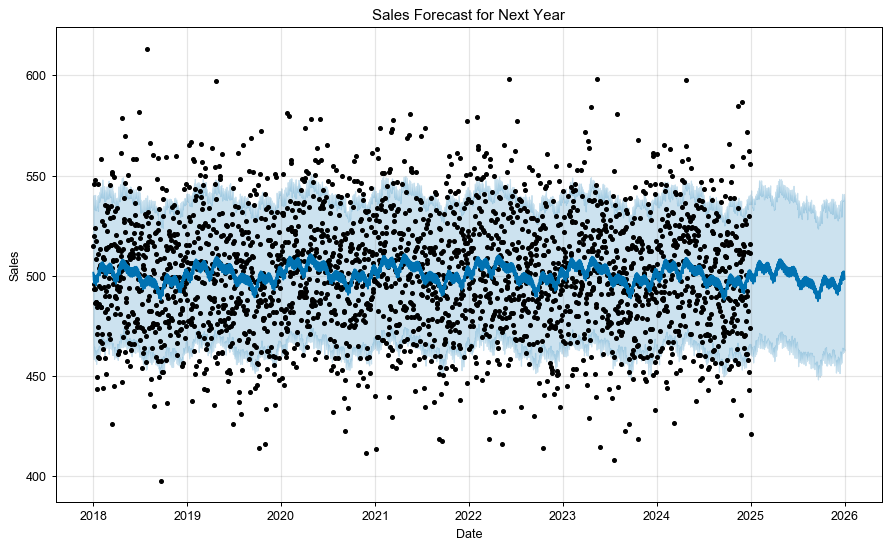

In [3]:
# 初始化 Prophet 模型
model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)

# 拟合模型
model.fit(data)

# 预测未来一年（2024年）
future = model.make_future_dataframe(periods=365)
forecast = model.predict(future)

# 可视化预测结果
fig1 = model.plot(forecast)
plt.title('Sales Forecast for Next Year')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

这张图展示了 Prophet 模型的初步预测结果，包括历史数据和未来一年的销售预测。

![原文参考图，当前结果见代码输出](attachments/img_033.png)

#### Step 3: 模型成分分解分析

为了进一步分析 Prophet 模型的预测，咱们可以分解出趋势、季节性和假期效应的影响。

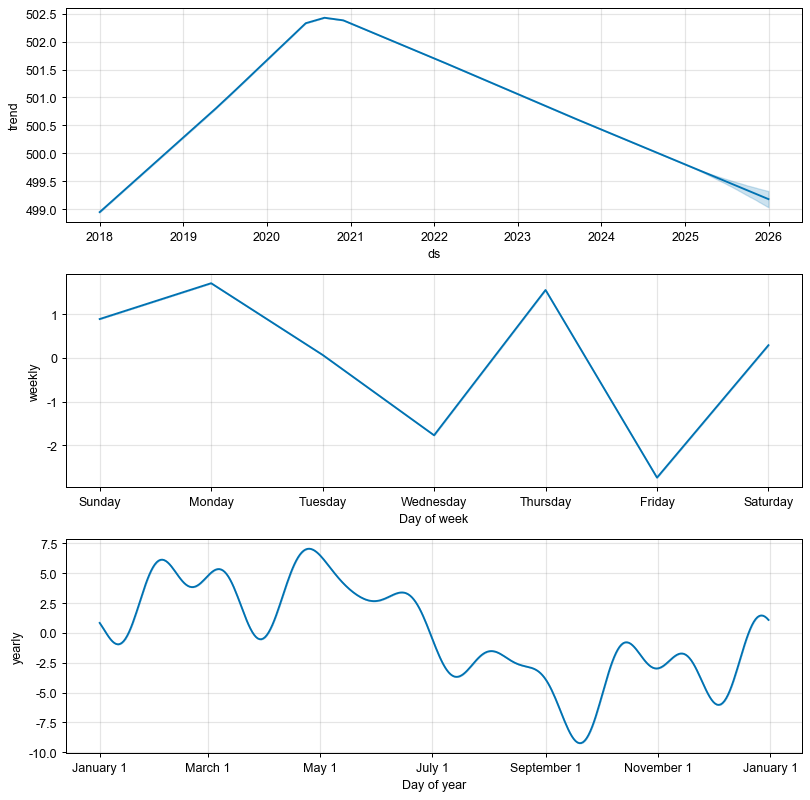

In [4]:
# 分解成分
fig2 = model.plot_components(forecast)
plt.show()

这张图展示了 Prophet 模型的不同组成部分，包括长期趋势、年度季节性以及周内模式。

1. **趋势图**：展示了时间序列的长期增长或衰退趋势。
2. **年度季节性**：展示了一年中的季节性变化，比如夏季、冬季的销售高峰。
3. **周内季节性**：展示了一周中的销售波动，例如周末销售较高。

![原文参考图，当前结果见代码输出](attachments/img_034.png)

#### Step 4: 假期效应

假设咱们要引入假期效应，例如黑色星期五和圣诞节对销售额的影响。咱们可以通过 Prophet 的 `add_country_holidays` 方法加入这些影响因素。

14:33:55 - cmdstanpy - INFO - Chain [1] start processing


14:33:55 - cmdstanpy - INFO - Chain [1] done processing


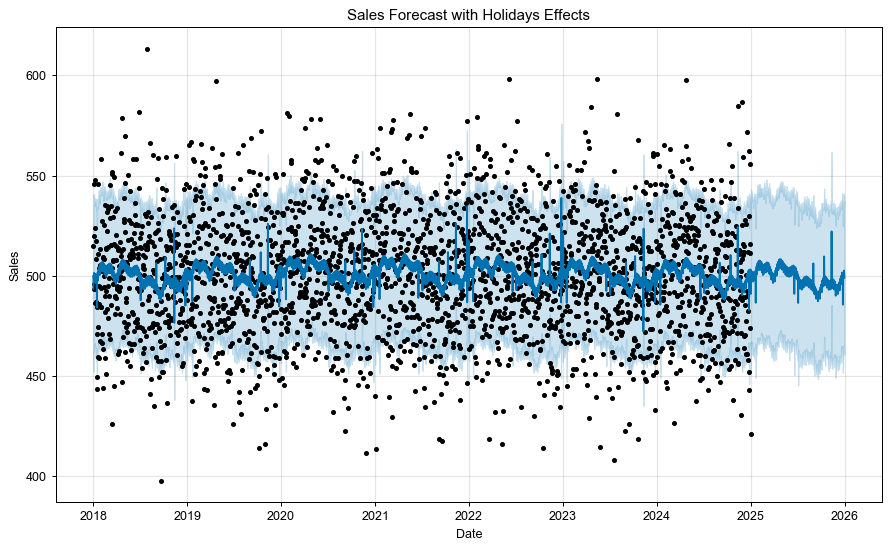

In [5]:
# 初始化 Prophet 模型，添加假期效应
model_with_holidays = Prophet(yearly_seasonality=True, weekly_seasonality=True)
model_with_holidays.add_country_holidays(country_name='US')

# 拟合模型
model_with_holidays.fit(data)

# 预测未来一年（包含假期效应）
future_with_holidays = model_with_holidays.make_future_dataframe(periods=365)
forecast_with_holidays = model_with_holidays.predict(future_with_holidays)

# 可视化预测结果（包含假期效应）
fig3 = model_with_holidays.plot(forecast_with_holidays)
plt.title('Sales Forecast with Holidays Effects')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

这张图展示了包含假期效应的销售预测，假期效应可能导致销售额在特定日期急剧增长或下降，例如圣诞节期间的销售激增。

![原文参考图，当前结果见代码输出](attachments/img_035.png)

#### Step 5: 模型优化

为了提升 Prophet 模型的预测性能，咱们可以调整模型的一些关键参数：

- **变化点（Change Points）**：调整趋势的变化点，增加模型对长期趋势变化的敏感性。
- **正则化参数**：通过调整趋势和季节性正则化参数，避免过拟合。

##### 调整变化点和正则化参数：

14:33:56 - cmdstanpy - INFO - Chain [1] start processing


14:33:56 - cmdstanpy - INFO - Chain [1] done processing


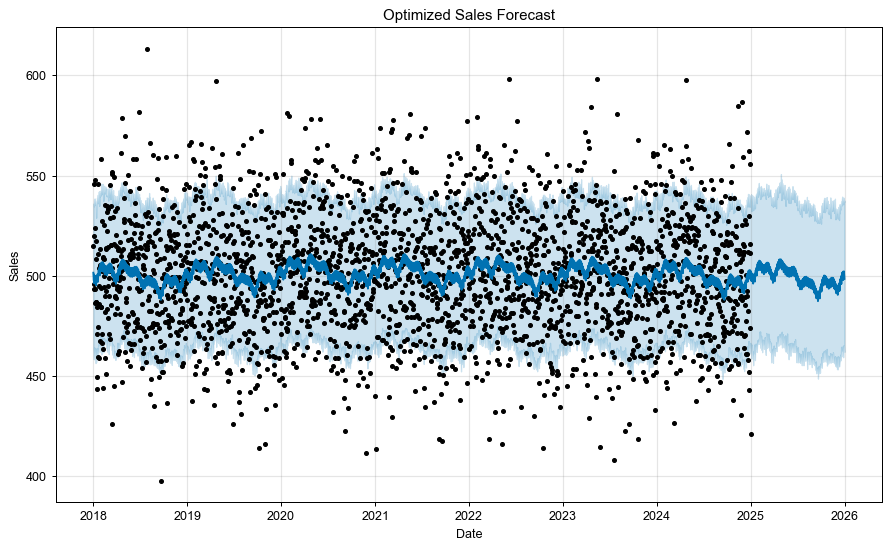

In [6]:
# 设置较高的变化点正则化强度，避免趋势过拟合
model_optimized = Prophet(
    changepoint_prior_scale=0.05,  # 较低的变化点正则化参数
    seasonality_prior_scale=10,    # 较高的季节性正则化参数
    yearly_seasonality=True, 
    weekly_seasonality=True
)

# 拟合优化后的模型
model_optimized.fit(data)

# 预测未来一年
future_optimized = model_optimized.make_future_dataframe(periods=365)
forecast_optimized = model_optimized.predict(future_optimized)

# 可视化优化后的预测结果
fig4 = model_optimized.plot(forecast_optimized)
plt.title('Optimized Sales Forecast')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

这张图展示了通过调整 Prophet 模型参数后，更加平滑和合理的销售预测结果。

![原文参考图，当前结果见代码输出](attachments/img_036.png)

1. **趋势解读**：通过 Prophet 模型的分解，咱们可以看到销售额的长期趋势。例如，销售额可能在某个时间段呈现线性增长，但由于假期或其他外部因素出现变化点，这时销售额可能有大幅波动。
2. **季节性效应**：年度季节性表明，销售额在特定季节波动较大，例如假期期间销售额上涨，冬季销售量可能降低。
3. **假期效应**：加入假期效应后，模型能够更加准确地捕捉到某些特殊时间段的销售波动，这对零售行业尤其重要。
4. **模型优化**：通过调整变化点和正则化参数，咱们避免了过拟合，得到了更稳定和更合理的预测结果。

## 模型分析

### 优点

1. **简单易用**：

   - **易上手**：Prophet 是一个面向非专家的数据科学工具，使用简单，特别适合时间序列预测的新手用户。它不需要用户进行复杂的特征工程，甚至对于趋势、季节性等因素，Prophet 都能自动检测和拟合。
   - **自动处理节假日和季节性变化**：Prophet 内置对节假日、季节性、周末等因素的处理，可以自动调整模型，尤其在零售、旅游等有明显季节性波动的行业中很有用。
2. **灵活性高**：

   - **趋势变化检测**：Prophet 自动检测趋势的变化点（change points），并能有效捕捉数据中存在的突然增长或衰退趋势。例如，在市场竞争变化时，销售额增长的速度可能突然发生改变，Prophet 可以对此进行自适应调整。
   - **长短期预测**：Prophet 可以适用于从日级别到年级别的时间序列数据，无论数据频率是高是低，适应性强。
3. **处理缺失数据的鲁棒性**：

   - **缺失值和异常值的耐受性**：相比其他时间序列算法，Prophet 对缺失值和异常值的敏感度较低，能够自动处理并拟合带有噪声的数据。
4. **可解释性**：

   - **可分解性**：Prophet 将时间序列分解为趋势、季节性、假期效应等部分，这样的分解方式具有较好的可解释性，方便理解模型的预测机制和每个成分对预测的贡献。

### 缺点

1. **无法处理高频数据**：对于超高频（如每秒或每分钟的金融数据等），Prophet 的性能会下降，因为它设计主要用于日常、每周、每月或季度的时间序列。面对这些高频数据，Prophet 的加性模型和趋势变化检测能力有限。
2. **对非线性趋势建模的局限性**：尽管 Prophet 支持线性和 Logistic 趋势建模，但面对更复杂的非线性变化（如明显的平稳期、振荡、反复周期等），它的能力相对不足。相较于深度学习模型如 LSTM，Prophet 在复杂数据模式捕捉上存在劣势。
3. **没有交互效应**：Prophet 主要基于时间来建模时间序列，无法处理交互特征（如多维时间序列的关联关系）。例如，销售额可能与价格、广告投放量等外部因素有关，Prophet 没有原生的支持来捕捉这种交互关系。
4. **假设趋势线性**：Prophet 假设趋势的增长是线性或 Logistic 的，面对更复杂或非线性的长期趋势（如波动、快速衰退等），其表现不够理想，可能会导致欠拟合。

### 与其他时间序列模型的对比

| **模型** | **原理** | **优点** | **缺点** | **适用场景** |
|-|-|-|-|-|
| **Prophet** | 基于加性模型（趋势+季节+假期），适用于时间序列分解 | 易用性强，能自动处理假期效应，适合趋势多变的数据 | 处理复杂非线性依赖能力较弱，无法直接用于高维特征 | 适用于具有明显季节性、节假日效应的中小型数据集 |
| **ARIMA** | 自回归（AR）+ 差分（I）+ 移动平均（MA） | 擅长建模自相关性强的时间序列，适合平稳或可差分平稳数据 | 需要进行数据平稳化处理，不能自动处理季节性和变化点 | 适用于线性增长或平稳的时间序列，适合具有强自相关性的场景 |
| **LSTM** | 基于 RNN 的深度学习模型，能够捕捉长序列依赖 | 适用于复杂非线性时间序列，能够自动学习滞后效应和趋势 | 需要大量数据，计算资源需求高，训练时间长，可解释性较低 | 适用于大规模、复杂模式的时间序列，如金融、能源预测 |
| **XGBoost** | 基于梯度提升的决策树模型，可用于回归和分类任务 | 适用于高维数据，能结合外部特征，提高预测能力 | 需要手动构造滞后特征，难以直接建模时间序列中的长期依赖 | 适用于多变量时间序列，特别是有外部因素影响的场景 |

### Prophet 的最佳应用场景

Prophet 是一种非常适合**中小型数据集**且**具有明显季节性和趋势变化的时间序列**的工具，尤其在下列场景下效果最佳：

1. **节假日效应显著的行业**：如零售、电商、旅游等，销售额受节假日影响大，且数据频率较低（天、周、月）。
2. **需要高可解释性**：Prophet 的加性分解模型让咱们能够清楚地看到趋势、季节性和假期效应的贡献，适合需要模型解释的场景。
3. **数据不稳定或缺失**：Prophet 在应对缺失值或异常值方面表现较好，适合数据质量不太高的情况。

### 其他算法的适用场景

1. **ARIMA**：适用于平稳的时间序列数据，特别是那些没有明显周期性或季节性效应的数据，且对自相关性有显著依赖。
2. **LSTM**：适合非线性复杂数据和长依赖关系明显的场景，如金融数据预测、能源负荷预测、传感器数据等。
3. **XGBoost**：适合有丰富滞后特征和外部特征的多维时间序列预测，尤其是那些可能与其他变量有强交互作用的数据。

总的来说，Prophet 是一个非常非常简单易用且灵活的时间序列工具，适合需要捕捉趋势、季节性和节假日效应的中小型数据集。当数据复杂度增加（如高频率、复杂非线性趋势或多维特征相互作用）时，LSTM、ARIMA 和 XGBoost 等其他模型可能是更好的选择。